In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from GASModels.dynamics import Dynamics
from GASModels.distributions.gamma_log_link import GammaLogLinkDistribution

In [2]:
xls = pd.read_excel('data/Energia Sudeste.xls')

In [3]:
dynamics = Dynamics(
    distribution = GammaLogLinkDistribution(),
    n = len(xls['data']),
    trend = None,
    seasonality = None,
    harmonics = 6,
    period = 12,
    time_varying_indices = [0],
    fixed_params_indices = [1],
    args = [0.05, 0.02]
)

In [ ]:
km = [0.0002]
kg = [0.0002]
gamma_0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
gamma_star_0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_0 = [np.log(xls['energia'][0])]
alpha = [0.00]

In [9]:
kg + km + gamma_0 + gamma_star_0 + mu_0 + alpha

[0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 0.02,
 np.int64(5623),
 0.0]

In [8]:
[(-2.0, 2.0), (-2.0, 2.0)] + [(None, None)] * 14

[(-2.0, 2.0),
 (-2.0, 2.0),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None)]

In [10]:
dynamics.objective(kg + km + gamma_0 + gamma_star_0 + mu_0 + alpha, xls['energia'])

[0.02 0.02 0.02 0.02 0.02 0.02]
gamma:  [0.02 0.02 0.02 0.02 0.02 0.02]
gamma_star:  [0.02 0.02 0.02 0.02 0.02 0.02]
score:  -1.0
kg:  0.02
gamma:  [ 0.          0.00732051  0.00732051  0.         -0.01267949 -0.02732051]
gamma_star:  [ 0.         -0.01267949 -0.02732051 -0.04       -0.04732051 -0.04732051]
score:  -1.0
kg:  0.02
gamma:  [-0.02       -0.02       -0.04       -0.06       -0.05464102 -0.02      ]
gamma_star:  [-0.02       -0.03464102 -0.04       -0.02        0.01464102  0.03464102]
score:  -1.0
kg:  0.02
gamma:  [-0.04       -0.05464102 -0.07464102 -0.04        0.02        0.01464102]
gamma_star:  [-0.04       -0.04       -0.00535898  0.04        0.02       -0.04      ]
score:  -1.0
kg:  0.02
gamma:  [-0.06       -0.08732051 -0.06196152  0.02       -0.01267949 -0.05267949]
gamma_star:  [-0.06       -0.02732051  0.04196152  0.02       -0.04732051  0.00732051]
score:  -1.0
kg:  0.02
gamma:  [-8.00000000e-02 -1.09282032e-01 -1.46410162e-02  6.93889390e-18
 -5.46410162e-02  2

c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gamma_log_link.py:21: RuntimeWarning: overflow encountered in exp
  scale = np.exp(lambda_ - alpha)  # theta = exp(lambda - alpha)
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gamma_log_link.py:49: RuntimeWarning: overflow encountered in exp
  dL_dlambda = np.exp(alpha) * (y / np.exp(lambda_) - 1)
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gamma_log_link.py:56: RuntimeWarning: overflow encountered in exp
  - y / np.exp(lambda_)


np.float64(inf)

In [6]:
dynamics.fit_in_sample(x['x'], xls['energia'])

[0.02 0.02 0.02 0.02 0.02 0.02]


array([6.33991480e+03, 6.08407807e+03, 5.48290559e+03, 5.81674412e+03,
       5.60083044e+03, 5.78476256e+03, 5.67287012e+03, 5.75930030e+03,
       5.70999934e+03, 5.74411795e+03, 5.78844602e+03, 5.47908064e+03,
       6.67942850e+03, 6.25637289e+03, 5.55111000e+03, 6.04549982e+03,
       5.78741760e+03, 6.01426148e+03, 5.91043486e+03, 5.99525425e+03,
       5.98927329e+03, 6.05416438e+03, 6.10117175e+03, 5.79392112e+03,
       7.16033002e+03, 6.56323610e+03, 5.71308681e+03, 6.40737013e+03,
       6.06258296e+03, 6.26487028e+03, 6.17479597e+03, 6.17128254e+03,
       6.25355716e+03, 6.24642541e+03, 6.28552073e+03, 5.96337040e+03,
       7.43951955e+03, 6.66403907e+03, 5.66860375e+03, 6.61627669e+03,
       6.26489031e+03, 6.47201285e+03, 6.38746696e+03, 6.38481258e+03,
       6.54997509e+03, 6.55180029e+03, 6.58632665e+03, 6.23992264e+03,
       7.89852347e+03, 6.87994897e+03, 5.73580661e+03, 6.95648054e+03,
       6.57891647e+03, 6.74900388e+03, 6.72570948e+03, 6.69542542e+03,
      

In [8]:
x = minimize(dynamics.objective, x0=kg + km + gamma_0 + gamma_star_0 + mu_0 + alpha, args=xls['energia'], method='L-BFGS-B', bounds=[(-2.0, 2.0), (-2.0, 2.0)] + [(0.0, None)] * 13 + [(-10.0, 10.0)])

gamma:  [0.02 0.02 0.02 0.02 0.02 0.02]
gamma_star:  [0.02 0.02 0.02 0.02 0.02 0.02]
mu0:  8.634620608292202
alpha:  0.0
logpdf:  9.64154104500936
logpdf:  9.627296644810311
logpdf:  9.652765366050458
logpdf:  9.665139968481038
logpdf:  9.70202776083854
logpdf:  9.698225867502954
logpdf:  9.711264840949225
logpdf:  9.704649300735332
logpdf:  9.764423751157448
logpdf:  9.727253735164677
logpdf:  9.77151240716897
logpdf:  9.7701823768387
logpdf:  9.744545672889554
logpdf:  9.738616324596247
logpdf:  9.748975124869283
logpdf:  9.766948470602873
logpdf:  9.783066085897604
logpdf:  9.797158266711934
logpdf:  9.78462442589371
logpdf:  9.854707980878207
logpdf:  9.8467844899706
logpdf:  9.843728854825425
logpdf:  9.904986392257895
logpdf:  9.826104372551807
logpdf:  9.882184197062076
logpdf:  9.790964290325274
logpdf:  9.85765926558113
logpdf:  9.78973791898858
logpdf:  9.834988614810385
logpdf:  9.780597141379674
logpdf:  9.805276902092757
logpdf:  9.843008202704109
logpdf:  9.80115377087694

c:\Users\ilang\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
logpdf:  inf
gamma:  [0. 0. 0. 0. 0. 0.]
gamma_star:  [2.e-02 1.e-08 0.e+00 0.e+00 0.e+00 0.e+00]
mu0:  6.747599885484231
alpha:  2.2104324306018697
logpdf:  42.315637736352684
logpdf:  409.0416277341436
logpdf:  319.5779363047301
logpdf:  197.0862896065212
l

In [9]:
x

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 3865.650413761205
        x: [ 1.088e-01  7.975e-03 ...  8.555e+00  2.942e-01]
      nit: 8
      jac: [ 9.200e-01  1.145e+03 ...  2.204e+00 -2.004e+02]
     nfev: 238
     njev: 14
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>

In [10]:
x['x']

array([1.08830692e-01, 7.97482765e-03, 1.70111170e-02, 1.42030120e-02,
       1.07740060e-02, 1.43110097e-02, 1.02149251e-02, 1.34570727e-02,
       2.00000000e-02, 1.17232680e-02, 1.46122549e-02, 1.07739868e-02,
       1.14923756e-02, 1.38107711e-02, 8.55489553e+00, 2.94243622e-01])

In [11]:
y = dynamics.fit_in_sample(x['x'], xls['energia'])

[0.01701112 0.01420301 0.01077401 0.01431101 0.01021493 0.01345707]


In [12]:
y

array([ 5624.3837894 ,  5535.45326835,  5231.05089005,  5466.9725183 ,
        5372.35302196,  5559.26233639,  5514.8420807 ,  5697.41709536,
        5725.98371283,  5761.53916351,  5848.4267533 ,  5721.71561977,
        6503.20756367,  6302.78321569,  5904.33868844,  6179.23925115,
        6037.18011946,  6219.34496699,  6149.45688205,  6311.11747721,
        6382.2157483 ,  6391.51014676,  6477.86221659,  6361.15556263,
        7177.2331458 ,  6942.75562788,  6415.15839268,  6760.34280036,
        6524.87590066,  6671.05038188,  6525.52594658,  6620.12841122,
        6680.70913742,  6573.07880681,  6608.19318483,  6430.37965885,
        7221.6711043 ,  6888.44901977,  6294.30432555,  6676.52973939,
        6592.84436544,  6745.89658507,  6652.18119127,  6816.42971337,
        6937.32268764,  6906.76199766,  6971.83733196,  6807.31681984,
        7693.32005253,  7284.66303016,  6622.86790757,  7060.7707332 ,
        7019.82241411,  7150.49294444,  7116.0773971 ,  7269.07642791,
      

In [ ]:
np.exp(0.998) * (y / np.exp(9.953) - 1)

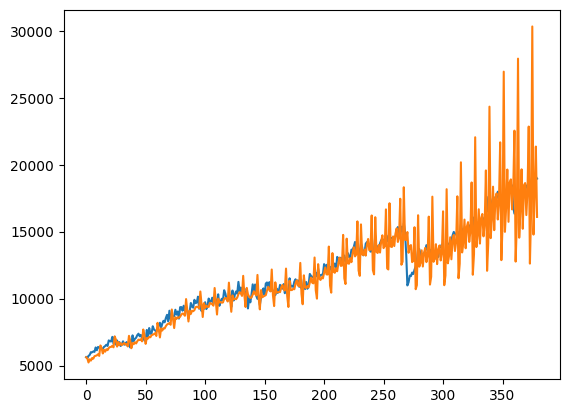

In [13]:
plt.plot(xls['energia'].values)
plt.plot(y)

In [8]:
y = dynamics.fit_in_sample([2.927e-02, 9.953, 0.998], xls['energia'])